In [1]:
#12.1 (b)
import numpy as np

def get_ising_hamiltonian(N, lam):
    #pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)

#construct 2^N x 2^N matrix representing an operator acting on a specific site
    def get_site_operator(op, site):
        mat = np.array([[1.0]], dtype=complex)
        for i in range(N):
            if i == site:
                mat = np.kron(mat, op)
            else:
                mat = np.kron(mat, np.eye(2))
        return mat

#initialize empty Hamiltonian matrix
    H = np.zeros((2**N, 2**N), dtype=complex)

    for n in range(N):
#periodic boundary conditions
        next_n = (n + 1) % N

#interaction term: sigma^x_n * sigma^x_{n+1}
        term_x = get_site_operator(sx, n) @ get_site_operator(sx, next_n)

#transverse field term: lambda * sigma^z_n
        term_z = lam * get_site_operator(sz, n)

        H += term_x + term_z

    return H

Computing gaps for lambda = {lam}...
  N = 2
    Hamiltonian fertig
    Eigenwerte fertig
  N = 4
    Hamiltonian fertig
    Eigenwerte fertig
  N = 6
    Hamiltonian fertig
    Eigenwerte fertig
  N = 8
    Hamiltonian fertig
    Eigenwerte fertig
  N = 10
    Hamiltonian fertig
    Eigenwerte fertig
  N = 10
    Hamiltonian fertig
    Eigenwerte fertig
Computing gaps for lambda = {lam}...
  N = 2
    Hamiltonian fertig
    Eigenwerte fertig
  N = 4
    Hamiltonian fertig
    Eigenwerte fertig
  N = 6
    Hamiltonian fertig
    Eigenwerte fertig
  N = 8
    Hamiltonian fertig
    Eigenwerte fertig
  N = 10
    Hamiltonian fertig
    Eigenwerte fertig
  N = 10
    Hamiltonian fertig
    Eigenwerte fertig
Computing gaps for lambda = {lam}...
  N = 2
    Hamiltonian fertig
    Eigenwerte fertig
  N = 4
    Hamiltonian fertig
    Eigenwerte fertig
  N = 6
    Hamiltonian fertig
    Eigenwerte fertig
  N = 8
    Hamiltonian fertig
    Eigenwerte fertig
  N = 10
    Hamiltonian fertig
    E

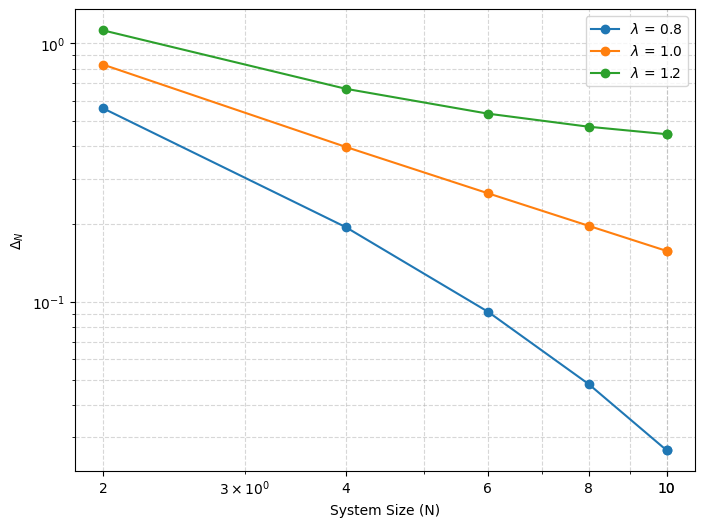

In [2]:
#12.1 (c) - dauert ca. 3min
import matplotlib.pyplot as plt

Ns = [2, 4, 6, 8, 10, 10]
lambdas = [0.8, 1.0, 1.2]

#dictionary to hold computed gaps
gaps_dict = {lam: [] for lam in lambdas}

#compute gaps
for lam in lambdas:
    print(r"Computing gaps for lambda = {lam}...")
    for N in Ns:
        print(f"  N = {N}", flush=True)

        H = get_ising_hamiltonian(N, lam)
        print("    Hamiltonian fertig", flush=True)

        #compute eigenvalues for a hermitian matrix
        eigenvalues = np.linalg.eigvalsh(H)
        print("    Eigenwerte fertig", flush=True)

        eigenvalues = np.sort(eigenvalues)

        #first gap is the difference between the lowest two eigenvalues
        gap = eigenvalues[1] - eigenvalues[0]
        gaps_dict[lam].append(gap)

#plotting the results double-log
plt.figure(figsize=(8, 6))

for lam in lambdas:
    plt.loglog(Ns, gaps_dict[lam], 'o-', label=r'$\lambda$' + f' = {lam}')

plt.xlabel('System Size (N)')
plt.ylabel(r'$\Delta_N$')
plt.xticks(Ns, [str(n) for n in Ns])  # Use explicit string labels for clarity
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

In [3]:
#12.1 (d) - dauert ca. 1min
Ns = [2, 4, 6, 8, 10, 12]
lam = 1.0
gaps = {}

# 1. Compute all required gaps at the critical point lambda = 1
for N in Ns:
    H = get_ising_hamiltonian(N, lam)
    eigenvalues = np.linalg.eigvalsh(H)
    gap = eigenvalues[1] - eigenvalues[0]
    gaps[N] = gap

# 2. Compute the negative discrete logarithmic derivative nu(N)
print(f"{'N':<5} | {'nu(N)':<10}")
print("-" * 18)

for N in [2, 4, 6, 8, 10]:
    delta_N = gaps[N]
    delta_N_plus_2 = gaps[N + 2]

    # Formula: nu(N) = -ln[Delta_(N+2) / Delta_N] / ln[(N+2)/N]
    nu_N = -np.log(delta_N_plus_2 / delta_N) / np.log((N + 2) / N)
    print(f"{N:<5} | {nu_N:.6f}")

N     | nu(N)     
------------------
2     | 1.058242
4     | 1.017840
6     | 1.008741
8     | 1.005202
10    | 1.003454
